In [ ]:
import gc
gc.collect()
import numpy as np
import pandas as pd
import os
import sys
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import json
import joblib


# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.analysis.feature_effects import FeatureEffects
from src.validity.validity_criteria import validate_polarization_curves

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_cv_results(save_dir='results', run_name='model_run'):
    """
    Load a previously saved model, best hyperparameters, and metrics.
    
    Parameters:
    - save_dir: folder containing the saved files
    - run_name: base name used when saving

    Returns:
    - model: trained sklearn or XGBoost model
    - best_params: dictionary of best hyperparameters
    - metrics: dictionary of evaluation metrics
    """

    model_path = os.path.join(save_dir, f"{run_name}_final_model.pkl")
    params_path = os.path.join(save_dir, f"{run_name}_best_params.json")
    metrics_path = os.path.join(save_dir, f"{run_name}_metrics.json")

    if not all(os.path.exists(p) for p in [model_path, params_path, metrics_path]):
        raise FileNotFoundError("[ERROR] One or more result files not found. Check save_dir and run_name.")

    model = joblib.load(model_path)

    with open(params_path, 'r') as f:
        best_params = json.load(f)

    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    print(f"[INFO] Loaded model from {model_path}")
    print(f"[INFO] Loaded hyperparameters from {params_path}")
    print(f"[INFO] Loaded metrics from {metrics_path}")

    return model, best_params, metrics


In [11]:
def plot_shap_bar(shap_df, top_n=13):
    plt.figure(figsize=(8, 5))
    plt.barh(shap_df["feature"][:top_n][::-1], shap_df["mean_abs_shap"][:top_n][::-1])
    plt.xlabel("Mean(|SHAP value|)")
    plt.title("SHAP Feature Importance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [55]:
def plot_sobol_index_convergence(sobol_results, index_type="ST", top_k=8, title=None, log_x=True, region=None):
    """
    Plot how each feature's Sobol index (S1 or ST) changes as sample size N increases.

    Parameters
    ----------
    sobol_results : dict
        Output from run_sobol_analysis(). Maps N → dict with key 'sobol_df' containing a DataFrame.
    index_type : str
        Which index to plot: "S1" for first-order or "ST" for total-order.
    top_k : int
        Number of top features to show based on the highest N.
    title : str or None
        Custom plot title. If None, defaults to f"{index_type} Index Convergence".
    log_x : bool
        Use log scale on the x-axis (sample size N).
    """
    assert index_type in ["S1", "ST"], "index_type must be 'S1' or 'ST'"

    # Pick top-k features at highest N
    max_N = max(sobol_results)
    df_max = sobol_results[max_N]['sobol_df']
    top_features = df_max.sort_values(index_type, ascending=False)["feature"].head(top_k).tolist()

    # Gather index values across N
    N_vals = sorted(sobol_results.keys())
    data = {f: [] for f in top_features}

    for N in N_vals:
        df = sobol_results[N]['sobol_df'].set_index("feature")
        for f in top_features:
            v = df.loc[f, index_type] if f in df.index else np.nan
            data[f].append(v)

    # Plot
    colors = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        "#A6761D", "#ffbb78", "#98df8a" #"#aec7e8"
    ]

    
    # Plot
    plt.figure(figsize=(10, 6))
    for i, f in enumerate(top_features):
        color = colors[i % len(colors)]  # Safe even if top_k > 13
        plt.plot(N_vals, data[f], marker="o", label=f, color=color)

    plt.ylabel(f"{index_type} Sobol Index")
    plt.xlabel("Sample Size N")
    plt.xticks([256, 512, 1024, 2048, 4096, 8192])
    plt.ylim(0, 1.05)
    if title is None:
        title = f"{index_type} Index Convergence for {region} Region" if region else f"{index_type} Index Convergence"
    plt.title(title)
    if log_x:
        plt.xscale("log")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(loc="upper right", bbox_to_anchor=(1.18, 1.0))
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_sobol_ranking(sobol_results, top_n=10):
    for N, result  in sobol_results.items():
        plt.figure(figsize=(8, 4))
        df = result['sobol_df']
        top = df.sort_values("S1", ascending=False).head(top_n)
        plt.barh(top["feature"][::-1], top["S1"][::-1])
        plt.title(f"Top {top_n} First-Order Sobol Indices (N={N})")
        plt.xlabel("S1")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [14]:
def save_FE_results(
    region_name,
    shap_df,
    sobol_results,
    save_dir="../results/xgboost",
    tag=None
):
    
    os.makedirs(save_dir, exist_ok=True)
    suffix = f"_{tag}" if tag else ""
    base = os.path.join(save_dir, f"xgb_{region_name}{suffix}")

    # 3. Save SHAP
    shap_df.to_csv(f"{base}_shap.csv", index=False)
    print(f"[INFO] Saved SHAP ranking to {base}_shap.csv")

    # 4. Save all Sobol results (DFs + Si + diagnostics) as one .pkl
    if sobol_results:
        sobol_path = f"{base}_sobol_results.pkl"
        joblib.dump(sobol_results, sobol_path)
        print(f"[INFO] Saved all Sobol results to {sobol_path}")

## **Load the model**

In [3]:
model_xgboost, best_params_xgboost, metrics_xgboost = load_cv_results(
    save_dir='../results/sm/xgboost',
    run_name='xgb_nconfig_all_with_outerCV'
)

[INFO] Loaded model from ../results/sm/xgboost\xgb_nconfig_all_with_outerCV_final_model.pkl
[INFO] Loaded hyperparameters from ../results/sm/xgboost\xgb_nconfig_all_with_outerCV_best_params.json
[INFO] Loaded metrics from ../results/sm/xgboost\xgb_nconfig_all_with_outerCV_metrics.json


## **Load valid data**

In [4]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

In [5]:
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df)) 

54754


In [6]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

In [7]:
df_exploded = data[columns].explode(['ifc', 'Ucell'], ignore_index=True)

## **Activation**

In [8]:
FE_act = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="activation")

In [9]:
FE_act_shap_results = FE_act.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (225248 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [12]:
FE_act_shap_results

,feature,mean_abs_shap
13,ifc,0.242468
10,i0_c_ref,0.043104
12,kappa_c,0.029053
0,Tfc,0.025665
1,Pa_des,0.022708
9,Re,0.010736
5,tau,0.010141
6,epsilon_mc,0.008145
11,kappa_co,0.007980
2,Sc,0.006424


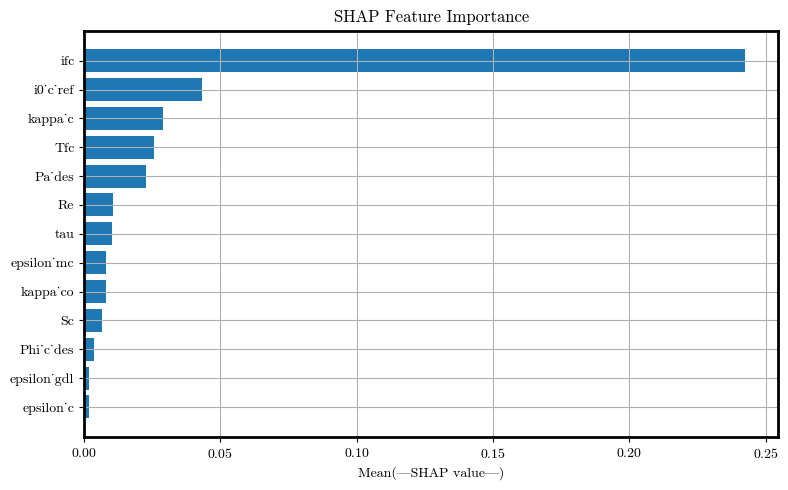

In [13]:
plot_shap_bar(FE_act_shap_results)

In [17]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_act_sobol_ = FE_act.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8717
[INFO] Sum S2 (unique pairs) = 1.1042
[INFO] Sum S1 + S2 = 1.9759 (should be ≈ 1)
[INFO] Sum ST = 1.0323 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9666
[INFO] Sum S2 (unique pairs) = 0.2224
[INFO] Sum S1 + S2 = 1.1890 (should be ≈ 1)
[INFO] Sum ST = 1.0725 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9664
[INFO] Sum S2 (unique pairs) = 0.0344
[INFO] Sum S1 + S2 = 1.0009 (should be ≈ 1)
[INFO] Sum ST = 1.0854 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9469
[INFO] Sum S2 (unique pairs) = -0.0287
[INFO] Sum S1 + S2 = 0.9182 (should be ≈ 1)
[INFO] Sum ST = 1.0710 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9497
[INFO] Sum S2 (unique pairs) = 0.0398
[INFO] Sum S1 + S2 = 0.9895 (should be ≈ 1)
[INFO] Sum ST = 1.0732 (may be > 1 due to overlaps)


In [19]:
list(FE_act_sobol_.keys())

[256, 512, 1024, 2048, 4096, 8192]

In [20]:
FE_act_sobol_

{256: {'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
  0      i0_c_ref  0.424212   (0.263, 0.586)  0.431829   (0.35, 0.514)   
  1       kappa_c  0.167441   (0.093, 0.242)  0.189183   (0.148, 0.23)   
  2           ifc  0.183631     (0.1, 0.268)  0.183209  (0.149, 0.218)   
  3           Tfc  0.050653  (-0.001, 0.102)  0.084060  (0.063, 0.105)   
  4        Pa_des  0.045691  (-0.003, 0.094)  0.077568  (0.058, 0.098)   
  5      kappa_co  0.005522  (-0.015, 0.027)  0.018754  (0.014, 0.024)   
  6            Sc  0.007203  (-0.014, 0.029)  0.012537  (0.009, 0.016)   
  7    epsilon_mc -0.009255  (-0.026, 0.008)  0.010617  (0.006, 0.015)   
  8           tau  0.003401   (-0.013, 0.02)  0.009175  (0.006, 0.012)   
  9            Re -0.001521  (-0.012, 0.009)  0.005264  (0.004, 0.007)   
  10    Phi_c_des  0.000046  (-0.011, 0.011)  0.005032  (0.002, 0.008)   
  11  epsilon_gdl -0.005695    (-0.012, 0.0)  0.002372  (0.001, 0.003)   
  12    epsilon_c -0.

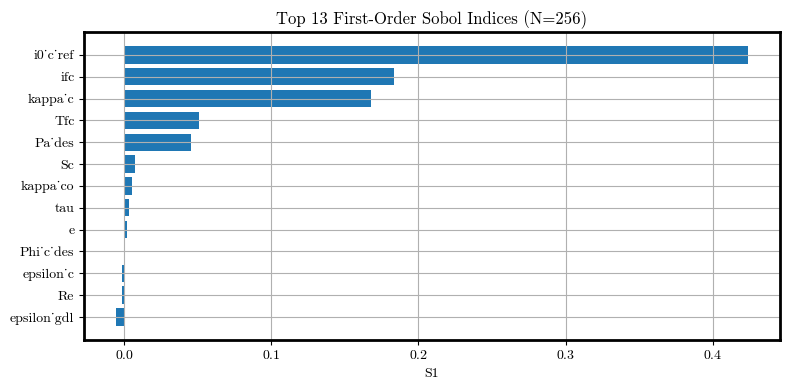

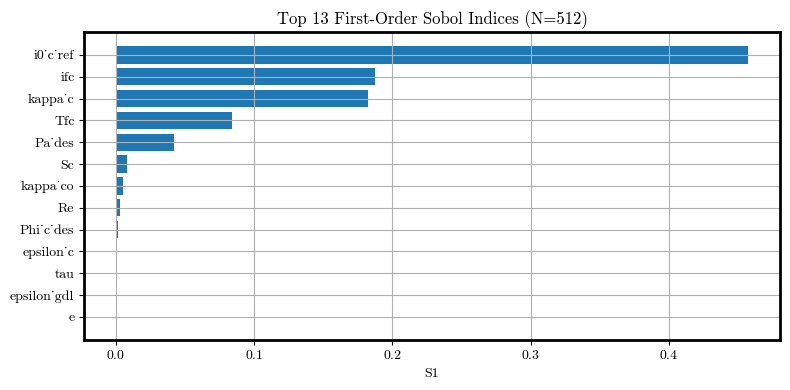

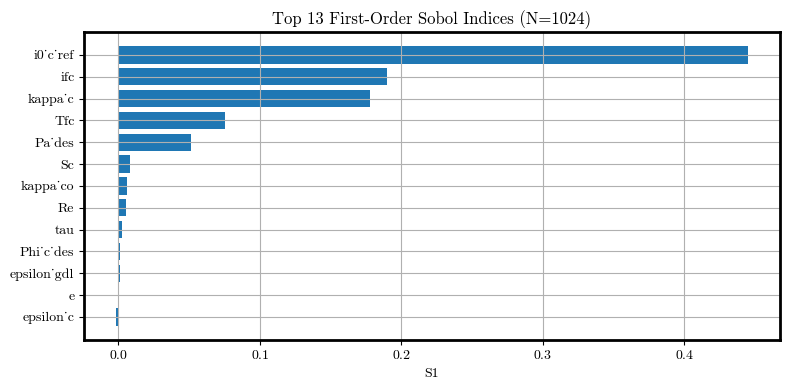

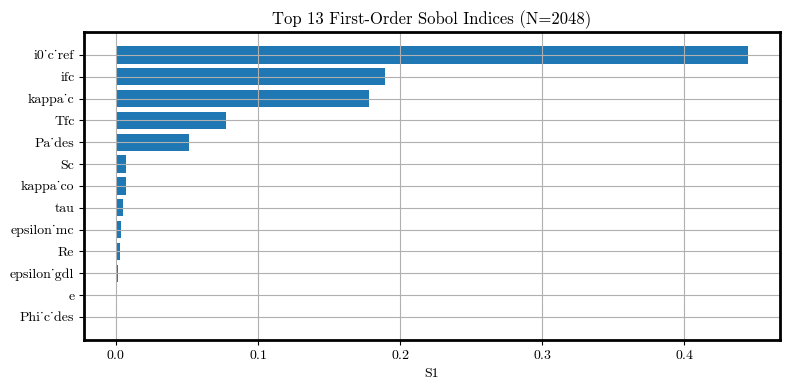

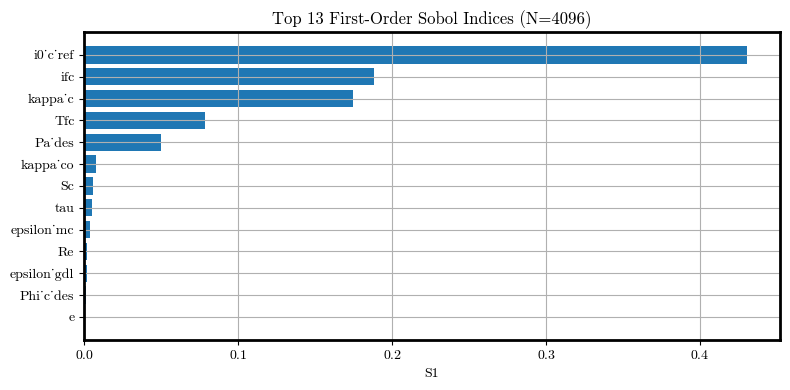

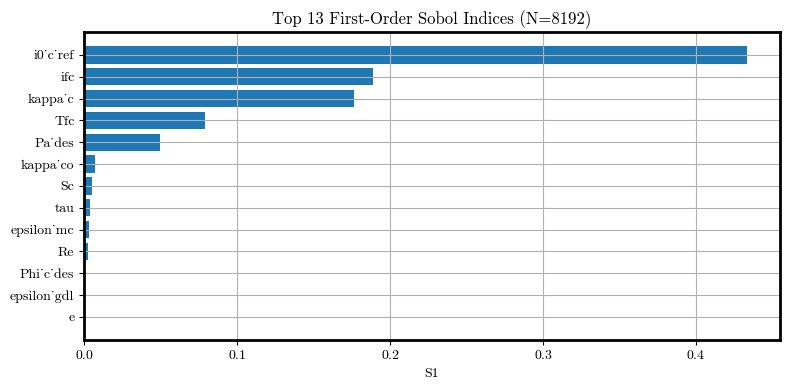

In [25]:
plot_sobol_ranking(FE_act_sobol_, top_n=13)

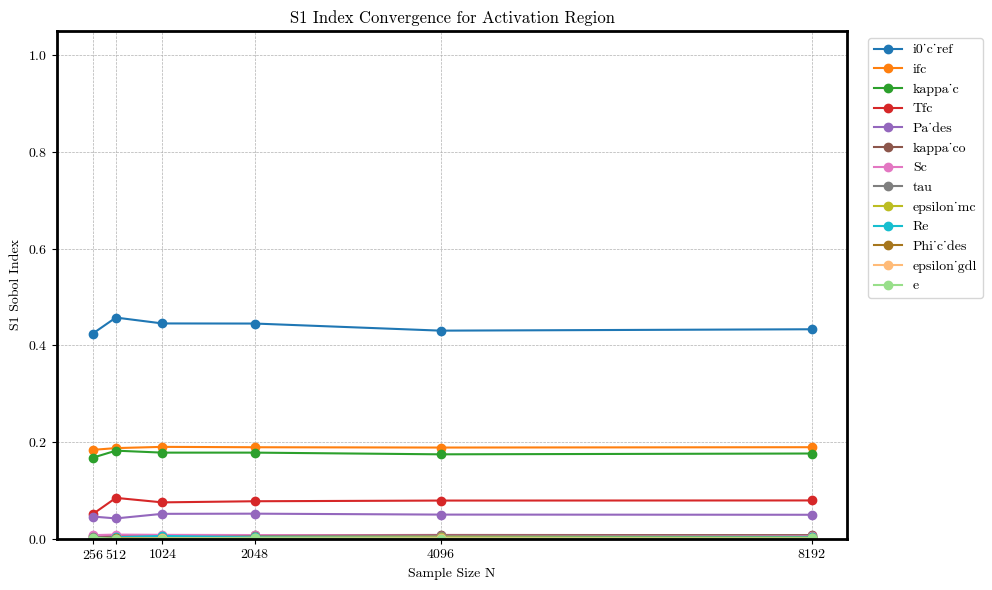

In [56]:
plot_sobol_index_convergence(FE_act_sobol_, top_k=13, index_type="S1", log_x=False, region = "Activation")

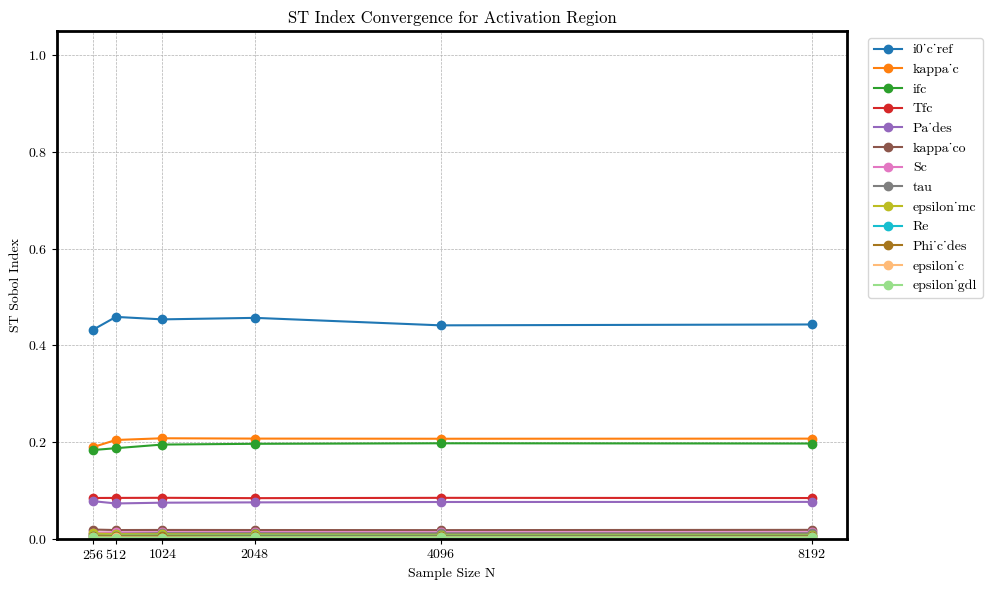

In [58]:
plot_sobol_index_convergence(FE_act_sobol_, top_k=13, index_type="ST", log_x=False, region = "Activation")

In [64]:
save_FE_results(
    region_name="activation",
    shap_df =FE_act_shap_results,
    sobol_results=FE_act_sobol_,
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_activation_17072025_shap.csv
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_activation_17072025_sobol_results.pkl


## **Ohmic**

In [30]:
FE_ohm = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="ohmic")

In [31]:
FE_ohm_shap_results = FE_ohm.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (675744 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [32]:
FE_ohm_shap_results

,feature,mean_abs_shap
13,ifc,0.068081
10,i0_c_ref,0.042955
1,Pa_des,0.030701
0,Tfc,0.030105
12,kappa_c,0.026845
9,Re,0.014886
5,tau,0.014009
6,epsilon_mc,0.011092
3,Phi_c_des,0.007050
2,Sc,0.005734


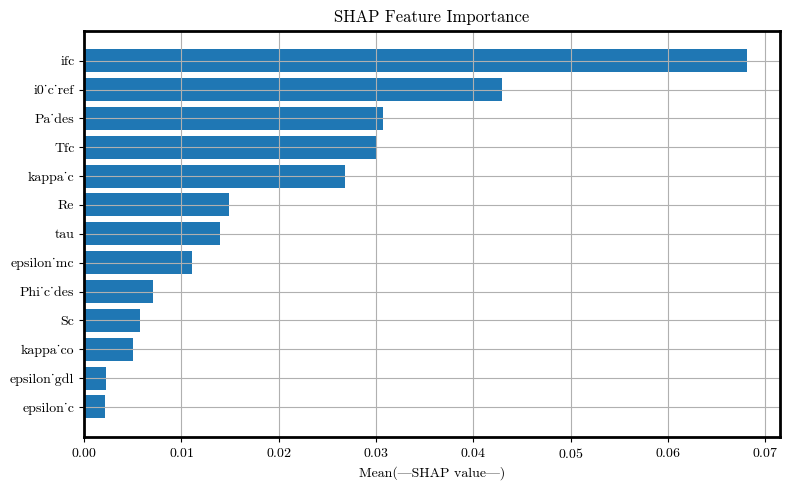

In [33]:
plot_shap_bar(FE_ohm_shap_results)

In [34]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_ohm_sobol_ = FE_ohm.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8695
[INFO] Sum S2 (unique pairs) = 1.1367
[INFO] Sum S1 + S2 = 2.0062 (should be ≈ 1)
[INFO] Sum ST = 1.0637 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9646
[INFO] Sum S2 (unique pairs) = 0.0229
[INFO] Sum S1 + S2 = 0.9875 (should be ≈ 1)
[INFO] Sum ST = 1.0985 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9501
[INFO] Sum S2 (unique pairs) = -0.0065
[INFO] Sum S1 + S2 = 0.9435 (should be ≈ 1)
[INFO] Sum ST = 1.0905 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9441
[INFO] Sum S2 (unique pairs) = -0.0666
[INFO] Sum S1 + S2 = 0.8775 (should be ≈ 1)
[INFO] Sum ST = 1.0823 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9398
[INFO] Sum S2 (unique pairs) = 0.0529
[INFO] Sum S1 + S2 = 0.9927 (should be ≈ 1)
[INFO] Sum ST = 1.0824 (may be > 1 due to overlaps)


In [35]:
FE_ohm_sobol_

{256: {'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
  0      i0_c_ref  0.307732   (0.174, 0.441)  0.310968  (0.244, 0.378)   
  1           ifc  0.243559    (0.157, 0.33)  0.256966  (0.211, 0.303)   
  2        Pa_des  0.109071   (0.041, 0.178)  0.140799  (0.108, 0.174)   
  3           Tfc  0.082820   (0.019, 0.147)  0.127938  (0.097, 0.159)   
  4       kappa_c  0.099965    (0.039, 0.16)  0.113832   (0.087, 0.14)   
  5           tau  0.006028   (-0.02, 0.033)  0.025365  (0.019, 0.032)   
  6    epsilon_mc  0.000909  (-0.026, 0.028)  0.024413  (0.017, 0.032)   
  7            Re  0.014430   (-0.012, 0.04)  0.023766  (0.017, 0.031)   
  8     Phi_c_des  0.005859  (-0.015, 0.027)  0.017774  (0.008, 0.027)   
  9            Sc  0.005432   (-0.01, 0.021)  0.008665  (0.006, 0.011)   
  10     kappa_co -0.005699  (-0.016, 0.005)  0.006351  (0.004, 0.009)   
  11  epsilon_gdl -0.006042  (-0.013, 0.001)  0.003183  (0.002, 0.004)   
  12    epsilon_c -0.

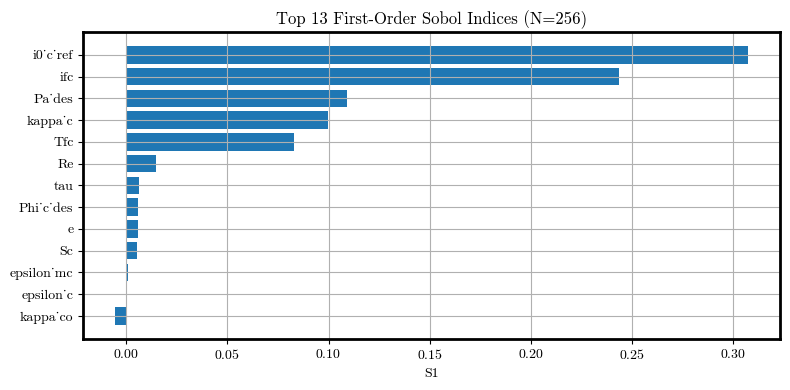

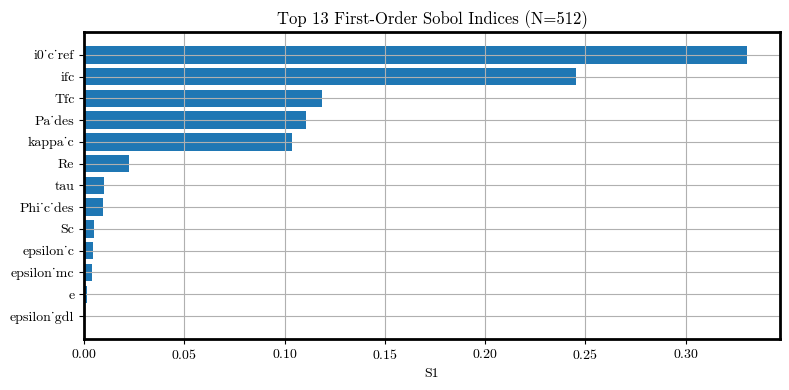

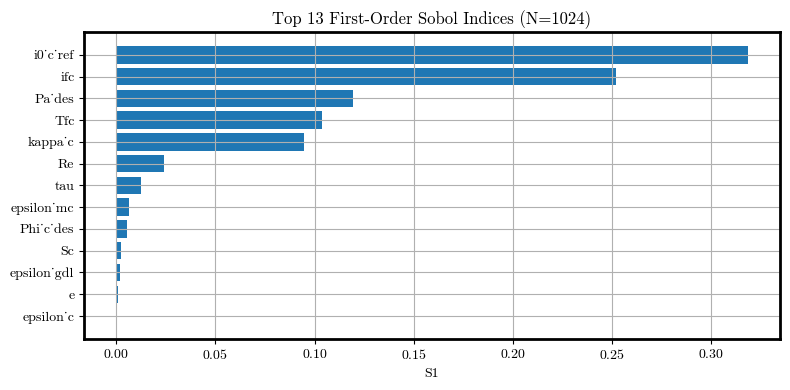

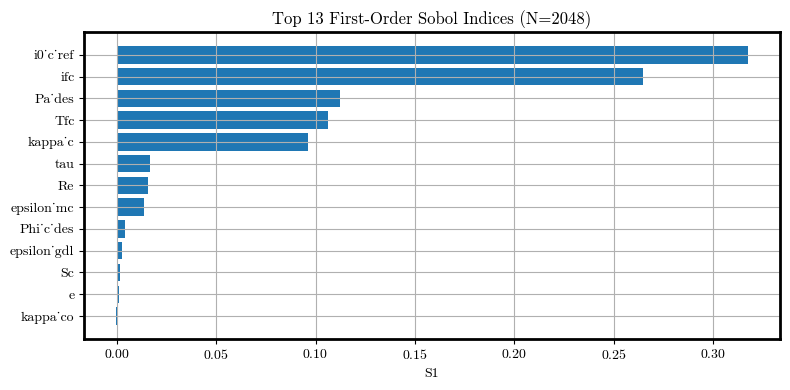

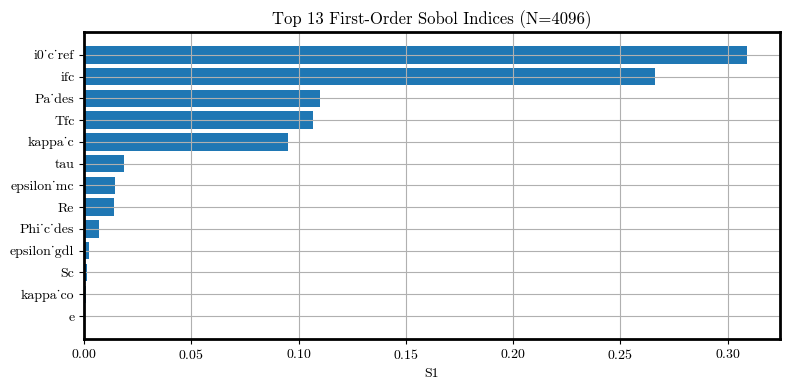

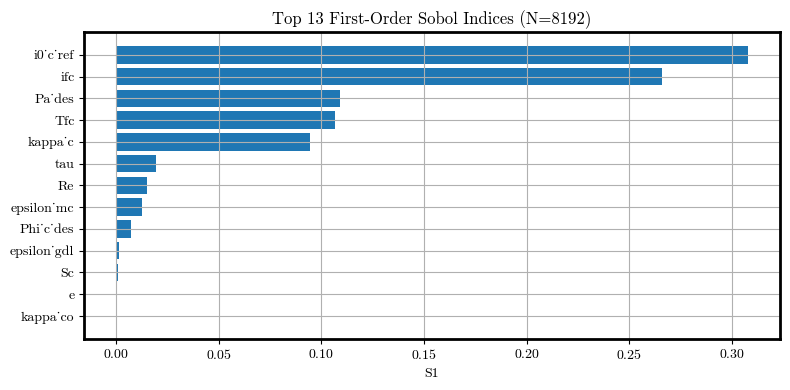

In [36]:
plot_sobol_ranking(FE_ohm_sobol_, top_n=13)

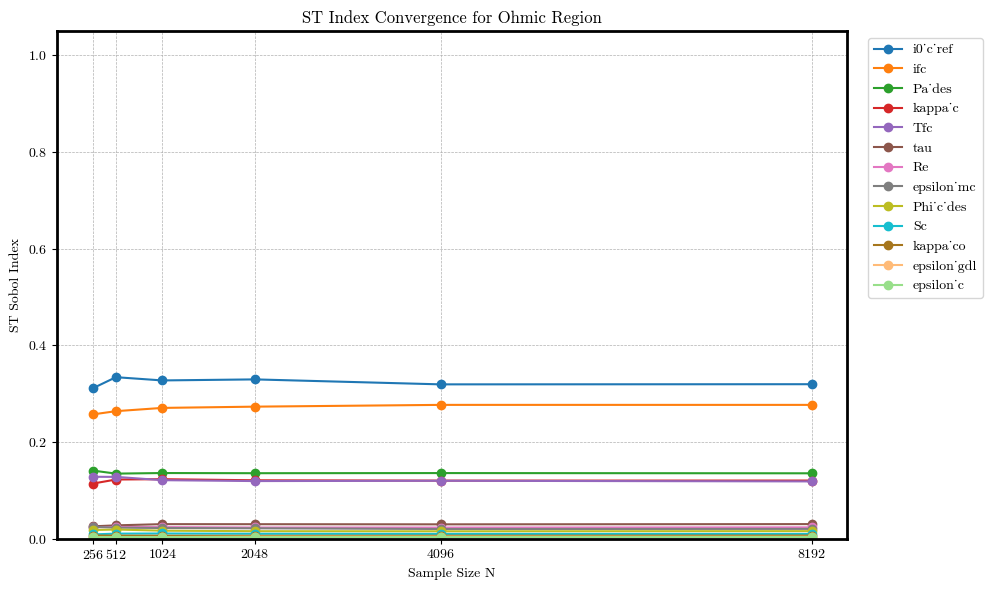

In [59]:
plot_sobol_index_convergence(FE_ohm_sobol_, top_k=13, index_type="ST", log_x=False, region = "Ohmic")

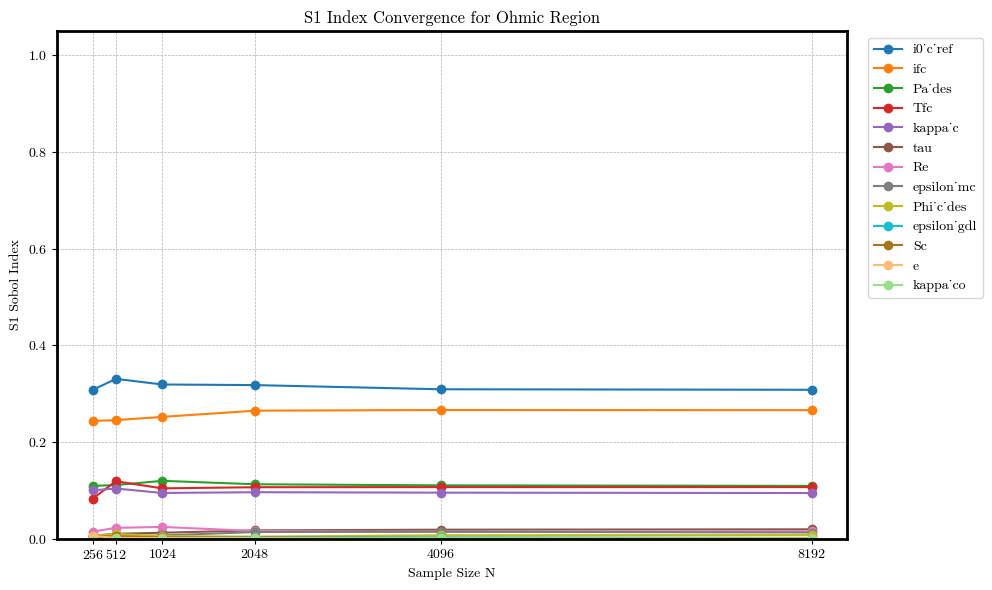

In [60]:
plot_sobol_index_convergence(FE_ohm_sobol_, top_k=13, index_type="S1", log_x=False, region = "Ohmic")

In [47]:
save_FE_results(
    region_name="ohmic",
    shap_df =FE_ohm_shap_results,
    sobol_results=FE_ohm_sobol_,
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_ohmic_17072025_shap.csv
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_ohmic_17072025_sobol_results.pkl


## **Mass transport**

In [48]:
FE_mass = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="mass_transport")

In [49]:
FE_mass_shap_results = FE_mass.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (844680 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [50]:
FE_mass_shap_results

,feature,mean_abs_shap
13,ifc,0.115942
10,i0_c_ref,0.042956
1,Pa_des,0.034779
0,Tfc,0.032639
9,Re,0.022520
12,kappa_c,0.021741
5,tau,0.018274
6,epsilon_mc,0.014542
3,Phi_c_des,0.008037
2,Sc,0.007622


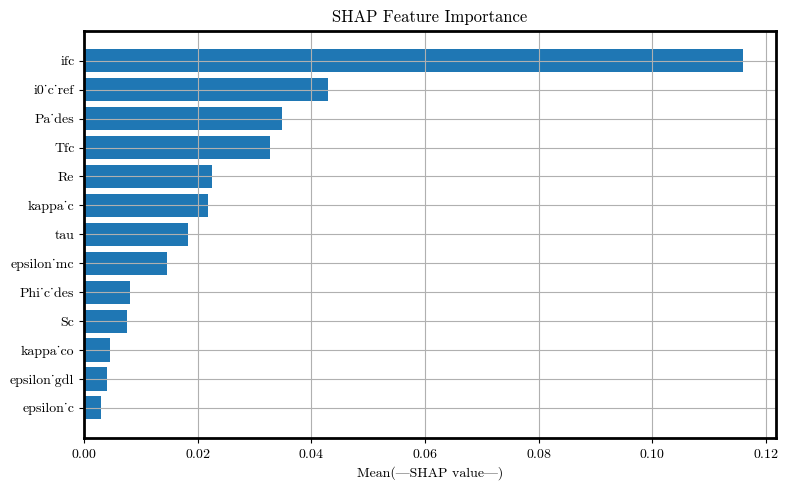

In [51]:
plot_shap_bar(FE_mass_shap_results)

In [52]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_mass_sobol_ = FE_mass.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8665
[INFO] Sum S2 (unique pairs) = 0.7304
[INFO] Sum S1 + S2 = 1.5969 (should be ≈ 1)
[INFO] Sum ST = 1.1482 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9497
[INFO] Sum S2 (unique pairs) = -0.1819
[INFO] Sum S1 + S2 = 0.7678 (should be ≈ 1)
[INFO] Sum ST = 1.2117 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9030
[INFO] Sum S2 (unique pairs) = 0.0325
[INFO] Sum S1 + S2 = 0.9355 (should be ≈ 1)
[INFO] Sum ST = 1.1595 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8975
[INFO] Sum S2 (unique pairs) = 0.0275
[INFO] Sum S1 + S2 = 0.9250 (should be ≈ 1)
[INFO] Sum ST = 1.1487 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8934
[INFO] Sum S2 (unique pairs) = 0.1054
[INFO] Sum S1 + S2 = 0.9987 (should be ≈ 1)
[INFO] Sum ST = 1.1470 (may be > 1 due to overlaps)


In [53]:
FE_mass_sobol_

{256: {'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
  0      i0_c_ref  0.305020   (0.185, 0.425)  0.313430  (0.246, 0.381)   
  1        Pa_des  0.196321   (0.119, 0.274)  0.219422  (0.174, 0.265)   
  2           Tfc  0.121929    (0.054, 0.19)  0.183902   (0.138, 0.23)   
  3            Re  0.128117   (0.063, 0.194)  0.139841  (0.108, 0.172)   
  4           tau  0.051832    (0.01, 0.094)  0.068505  (0.053, 0.084)   
  5    epsilon_mc  0.041615  (-0.005, 0.088)  0.063940  (0.047, 0.081)   
  6       kappa_c -0.002194   (-0.04, 0.036)  0.044138  (0.032, 0.056)   
  7            Sc  0.022671   (-0.014, 0.06)  0.038665  (0.027, 0.051)   
  8     Phi_c_des  0.002600  (-0.023, 0.028)  0.031780  (0.016, 0.048)   
  9   epsilon_gdl -0.000911  (-0.028, 0.026)  0.026068  (0.018, 0.035)   
  10     kappa_co -0.006087  (-0.023, 0.011)  0.009396  (0.005, 0.014)   
  11    epsilon_c -0.001462  (-0.016, 0.013)  0.006925   (0.004, 0.01)   
  12            e  0.

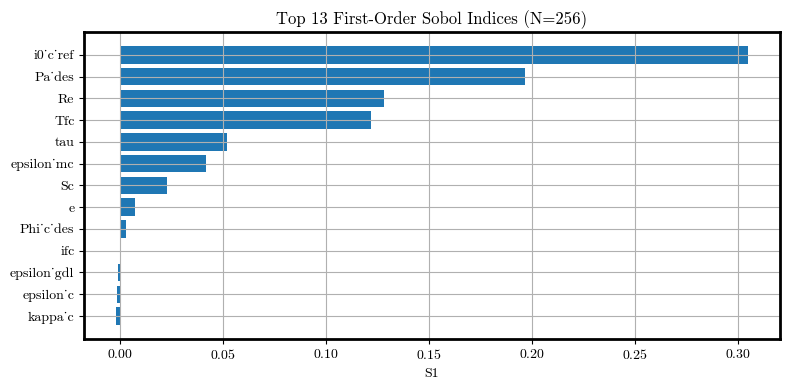

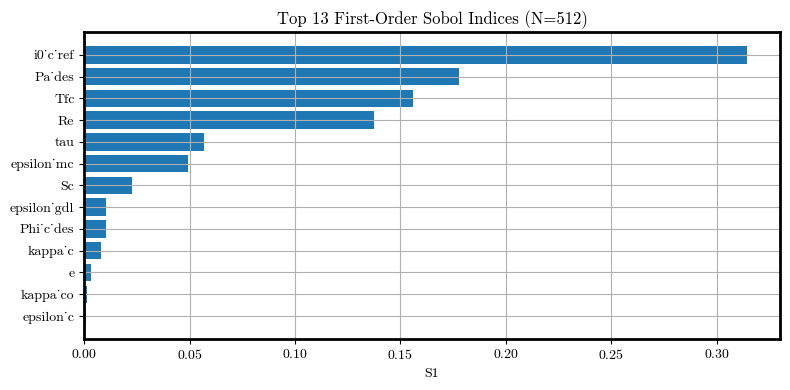

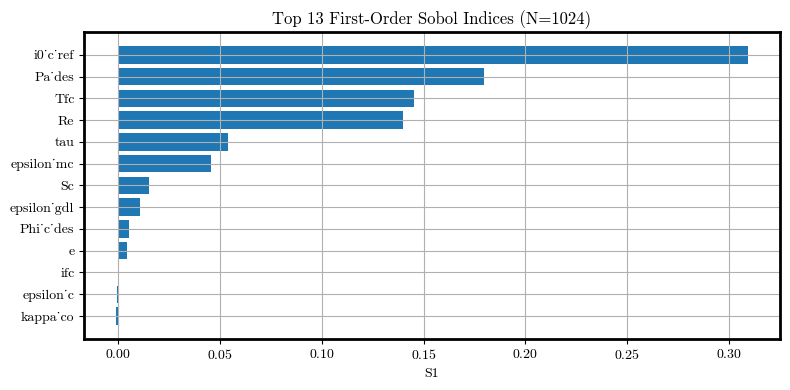

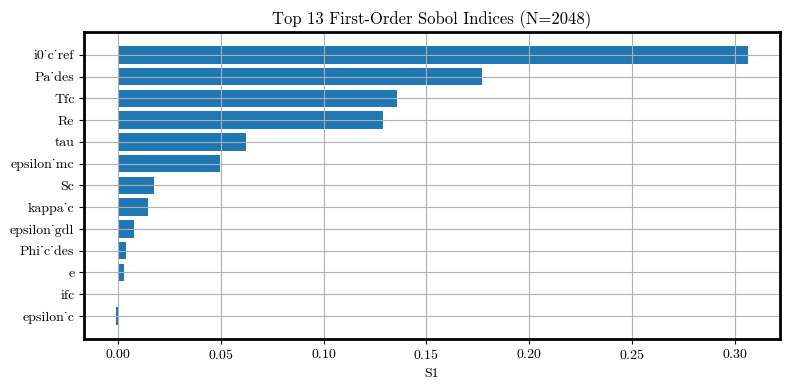

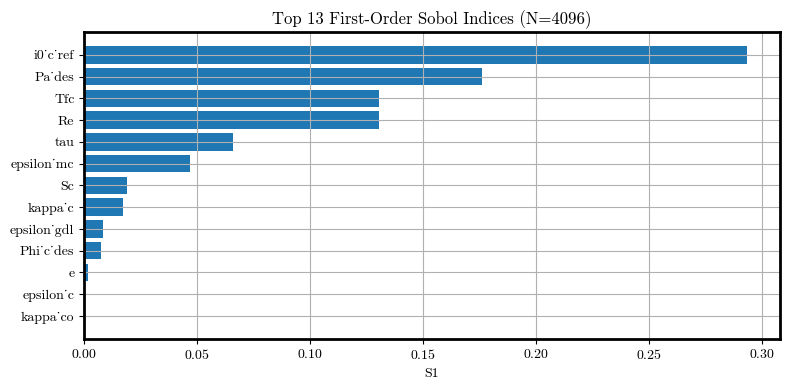

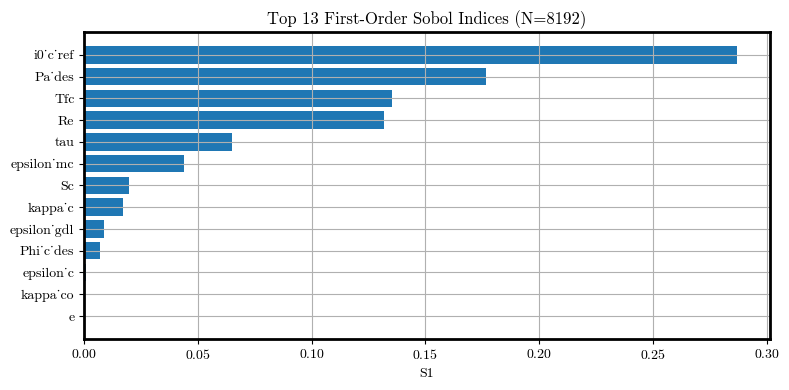

In [54]:
plot_sobol_ranking(FE_mass_sobol_, top_n=13)

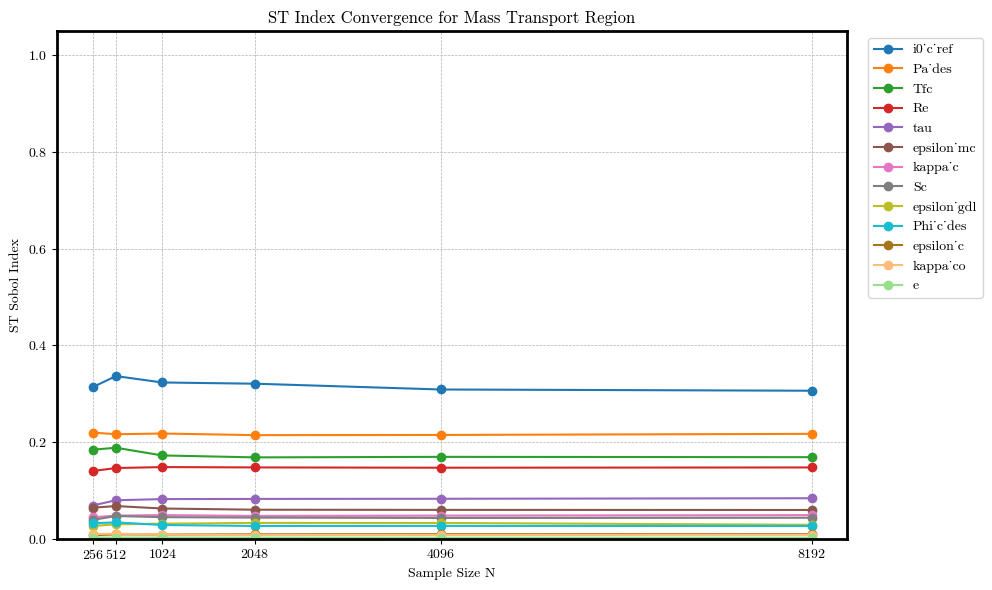

In [61]:
plot_sobol_index_convergence(FE_mass_sobol_, top_k=13, index_type="ST", log_x=False, region = "Mass Transport")

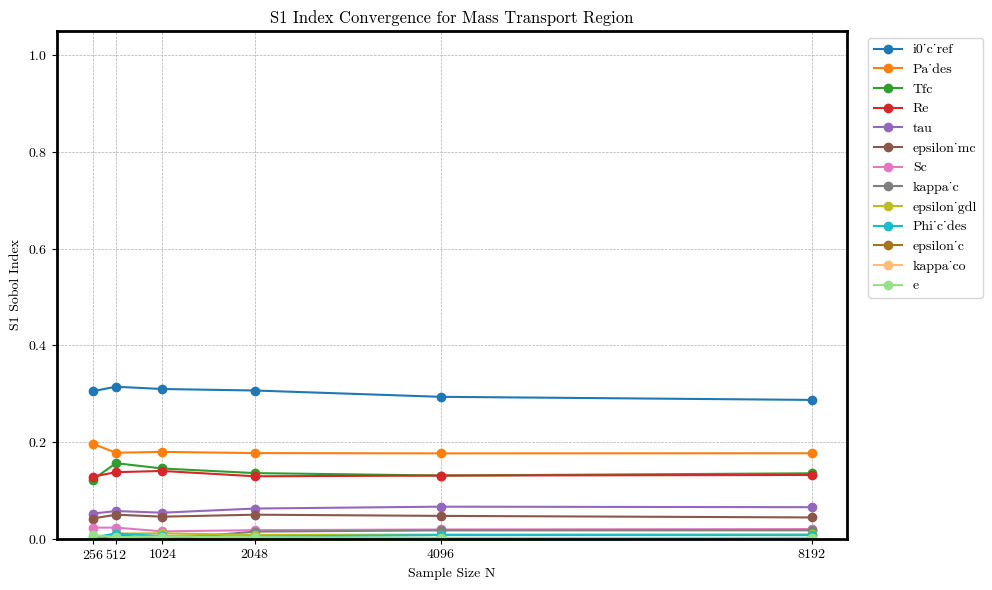

In [62]:
plot_sobol_index_convergence(FE_mass_sobol_, top_k=13, index_type="S1", log_x=False, region = "Mass Transport")

In [63]:
save_FE_results(
    region_name="mass_transport",
    shap_df =FE_mass_shap_results,
    sobol_results=FE_mass_sobol_,
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_mass_transport_17072025_shap.csv
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_mass_transport_17072025_sobol_results.pkl
